Movie Review Sentiment Analysis
Classifies IMDB movie reviews as Positive/Negative using Python, pandas, scikit-learn, and NLTK. Supports analysis of movie sentiments with TF-IDF features and logistic regression.

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [3]:
full_df = pd.read_csv('IMDB_Dataset.csv')
df = full_df.sample(n=10000, random_state=42).reset_index(drop=True)

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Dataset Loaded Successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


Dataset Loaded Successfully!
Dataset Shape: (10000, 2)
                                              review  sentiment
0  I really liked this Summerslam due to the look...          1
1  Not many television shows appeal to quite as m...          1
2  The film quickly gets to a major chase scene w...          0
3  Jane Austen would definitely approve of this o...          1
4  Expectations were somewhat high for me when I ...          0


 2. CLEAN REVIEWS (PREPROCESSING LOOP)

In [4]:
print("Cleaning text...")
corpus = []
stop_words = set(stopwords.words('english'))

for i in range(len(df)):
    review = re.sub(r'<br\s*/?>', ' ', str(df['review'][i]))  # Remove HTML tags
    review = re.sub(pattern='[^a-zA-Z]', repl=' ', string=review) # Keep only letters
    review = review.lower().split()
    review = [word for word in review if word not in stop_words]
    corpus.append(' '.join(review))

print("Text cleaning complete!")

Cleaning text...
Text cleaning complete!


3. COUNT VECTORIZER

In [5]:
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=15000)
X = vectorizer.fit_transform(corpus)
y = df['sentiment'].values

4. TRAIN-TEST SPLIT (80% Train, 20% Test)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

5. MODEL SELECTION (LOGISTIC REGRESSION)

In [7]:
classifier = LogisticRegression(C=1.0, max_iter=1000)
classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

 6. TESTING & EVALUATING SCORES


--------- PERFORMANCE SCORES --------
Accuracy Score  : 86.15%
Precision Score : 84.74%
Recall Score    : 88.21%


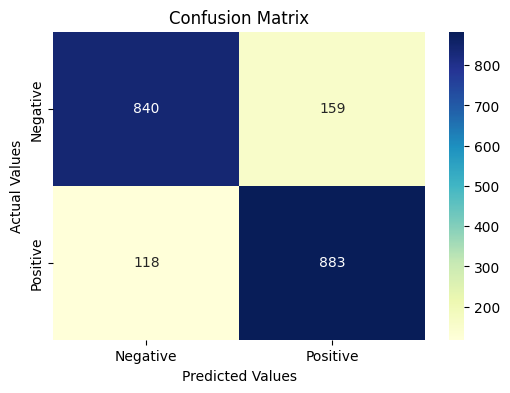

In [8]:
y_pred = classifier.predict(X_test)

score_acc = accuracy_score(y_test, y_pred)
score_prec = precision_score(y_test, y_pred)
score_rec = recall_score(y_test, y_pred)

print("\n--------- PERFORMANCE SCORES --------")
print(f"Accuracy Score  : {round(score_acc * 100, 2)}%")
print(f"Precision Score : {round(score_prec * 100, 2)}%")
print(f"Recall Score    : {round(score_rec * 100, 2)}%")

# Visualizing Confusion Matrix Graph
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu", 
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')
plt.show()


7. ANALYZING REAL REVIEWS (PREDICTION FUNCTION)

In [10]:
def predict_imdb_sentiment(sample_review):
    # Standard Preprocessing Pipeline
    sample_review = re.sub(r'<br\s*/?>', ' ', sample_review)
    sample_review = re.sub(pattern='[^a-zA-Z]', repl=' ', string=sample_review)
    sample_review = sample_review.lower().split()
    sample_review = [word for word in sample_review if word not in stop_words]
    final_review = ' '.join(sample_review)
    
    # Vectorize and Predict
    numeric_vector = vectorizer.transform([final_review])
    prediction = classifier.predict(numeric_vector)
    
    return "POSITIVE 🟢" if prediction == 1 else "NEGATIVE 🔴"


random_reviews = [
    "this movie is a amazing movie i ever seen",                         
    "Total waste of money! The acting was flat and the script was joke.", 
    "I had low expectations but this was absolute gold. Loved it!",
    "Oh brilliant, another generic sequel nobody asked for",      
    "The cinematography was beautiful, but the pacing was too slow.",     
             
    ]

print("\n--- BATCH PERFORMANCE TEST ON RANDOM REVIEWS ---")
print("-" * 65)

for i, review in enumerate(random_reviews, 1):
    prediction = predict_imdb_sentiment(review)
    print(f"Test-{i}")
    print(f"Review   : \"{review}\"")
    print(f"Predicted: {prediction}")
    print("-" * 65)



--- BATCH PERFORMANCE TEST ON RANDOM REVIEWS ---
-----------------------------------------------------------------
Test-1
Review   : "this movie is a amazing movie i ever seen"
Predicted: POSITIVE 🟢
-----------------------------------------------------------------
Test-2
Review   : "Total waste of money! The acting was flat and the script was joke."
Predicted: NEGATIVE 🔴
-----------------------------------------------------------------
Test-3
Review   : "I had low expectations but this was absolute gold. Loved it!"
Predicted: POSITIVE 🟢
-----------------------------------------------------------------
Test-4
Review   : "Oh brilliant, another generic sequel nobody asked for"
Predicted: POSITIVE 🟢
-----------------------------------------------------------------
Test-5
Review   : "The cinematography was beautiful, but the pacing was too slow."
Predicted: POSITIVE 🟢
-----------------------------------------------------------------
